In [1]:
!pip install transformers datasets peft accelerate scikit-learn seaborn

In [3]:
import torch
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq
)

from peft import LoraConfig, get_peft_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter

# REPRODUCIBILITY

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


# PROJECT CONFIGURATION

In [5]:
MODEL_NAME = "google/flan-t5-base"
MAX_LENGTH = 512
BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 3e-5

# LOAD LARGE DATASET

In [6]:
dataset = load_dataset("pubmed_qa", "pqa_labeled")

print(dataset)

# Label distribution
labels = [example["final_decision"] for example in dataset["train"]]
print("Label Distribution:", Counter(labels))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['pubid', 'question', 'context', 'long_answer', 'final_decision'],
        num_rows: 1000
    })
})
Label Distribution: Counter({'yes': 552, 'no': 338, 'maybe': 110})


In [7]:
train_test = dataset["train"].train_test_split(test_size=0.3, seed=SEED)
val_test = train_test["test"].train_test_split(test_size=0.5, seed=SEED)

raw_train = train_test["train"]
raw_val = val_test["train"]
raw_test = val_test["test"]

print("Train:", len(raw_train))
print("Validation:", len(raw_val))
print("Test:", len(raw_test))

Train: 700
Validation: 150
Test: 150


# TOKENIZER

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def preprocess(example):

    context_text = " ".join(example["context"]["contexts"])

    input_text = (
        f"Context: {context_text}\n"
        f"Question: {example['question']}\n"
        "Answer yes, no or maybe:"
    )

    target_text = example["final_decision"]

    model_inputs = tokenizer(
        input_text,
        max_length=MAX_LENGTH,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        target_text,
        max_length=8,
        truncation=True,
        padding="max_length"
    )

    label_ids = labels["input_ids"]

    # Correct masking
    label_ids = [
        token if token != tokenizer.pad_token_id else -100
        for token in label_ids
    ]

    model_inputs["labels"] = label_ids

    return model_inputs

# Apply preprocessing AFTER splitting
train_dataset = raw_train.map(preprocess, remove_columns=raw_train.column_names)
val_dataset = raw_val.map(preprocess, remove_columns=raw_val.column_names)
test_dataset = raw_test.map(preprocess, remove_columns=raw_test.column_names)

print("Processed columns:", train_dataset.column_names)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Processed columns: ['input_ids', 'attention_mask', 'labels']


# EVALUATION FUNCTION

In [9]:
def evaluate_model(model, dataset, name):

    model.eval()
    preds = []
    labels = []

    for i in range(len(dataset)):
        sample = dataset[i]

        input_ids = torch.tensor(sample["input_ids"]).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model.generate(input_ids=input_ids, max_new_tokens=5)

        pred_text = tokenizer.decode(outputs[0],
                                     skip_special_tokens=True).lower()

        if "yes" in pred_text:
            preds.append("yes")
        elif "no" in pred_text:
            preds.append("no")
        else:
            preds.append("maybe")

        label_text = tokenizer.decode(
            [t for t in sample["labels"] if t != -100],
            skip_special_tokens=True
        ).lower()

        labels.append(label_text)

    acc = accuracy_score(labels, preds)

    print(f"\n{name} Accuracy:", acc)
    print(classification_report(labels, preds))

    cm = confusion_matrix(labels, preds,
                          labels=["yes","no","maybe"])

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=["yes","no","maybe"],
                yticklabels=["yes","no","maybe"],
                cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    return acc


# BASELINE MODEL

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]


Baseline Accuracy: 0.5066666666666667
              precision    recall  f1-score   support

       maybe       0.08      0.06      0.07        16
          no       0.56      0.18      0.27        55
         yes       0.54      0.82      0.65        79

    accuracy                           0.51       150
   macro avg       0.39      0.36      0.33       150
weighted avg       0.50      0.51      0.45       150



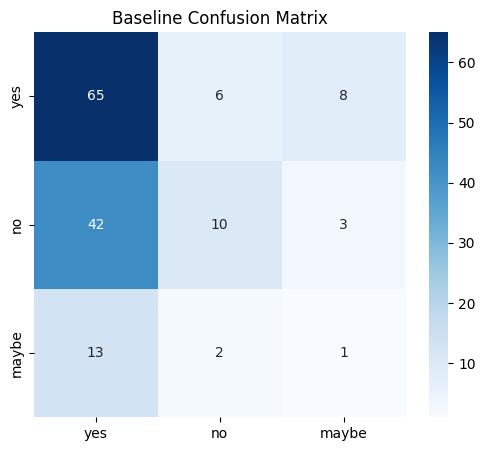

In [10]:
baseline_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
baseline_acc = evaluate_model(baseline_model, test_dataset, "Baseline")

# FULL FINE-TUNING (FFT)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Step,Training Loss
50,0.000000
100,0.000000
150,0.000000
200,0.000000
250,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Full Fine-Tuned Accuracy: 0.5066666666666667
              precision    recall  f1-score   support

       maybe       0.08      0.06      0.07        16
          no       0.56      0.18      0.27        55
         yes       0.54      0.82      0.65        79

    accuracy                           0.51       150
   macro avg       0.39      0.36      0.33       150
weighted avg       0.50      0.51      0.45       150



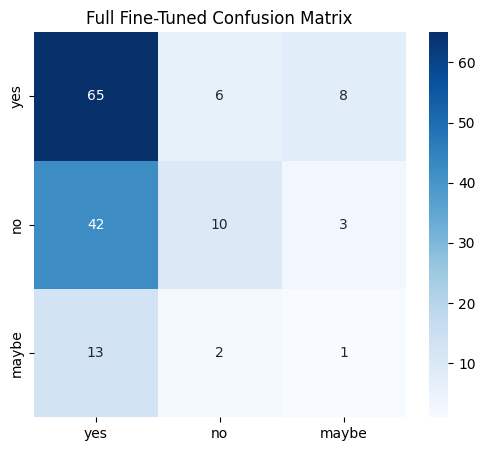

In [11]:
fft_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)

training_args_fft = TrainingArguments(
    output_dir="./fft_results",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer_fft = Trainer(
    model=fft_model,
    args=training_args_fft,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=fft_model)
)

trainer_fft.train()

fft_acc = evaluate_model(fft_model, test_dataset, "Full Fine-Tuned")

# LoRA (Parameter Efficient Fine-Tuning)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Step,Training Loss
50,0.000000
100,0.000000
150,0.000000
200,0.000000
250,0.000000



LoRA Fine-Tuned Accuracy: 0.5066666666666667
              precision    recall  f1-score   support

       maybe       0.08      0.06      0.07        16
          no       0.56      0.18      0.27        55
         yes       0.54      0.82      0.65        79

    accuracy                           0.51       150
   macro avg       0.39      0.36      0.33       150
weighted avg       0.50      0.51      0.45       150



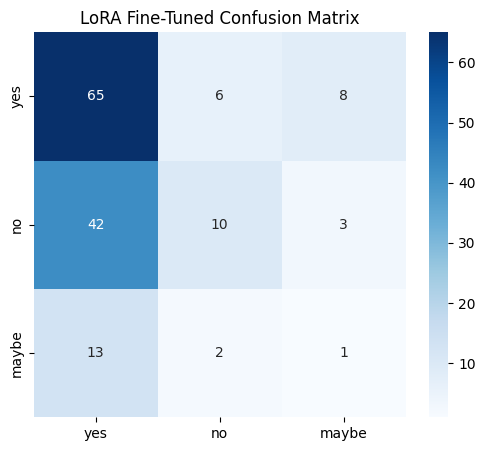

In [12]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q", "v"],
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_2_SEQ_LM"
)

lora_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
lora_model = get_peft_model(lora_model, lora_config)

training_args_lora = TrainingArguments(
    output_dir="./lora_results",
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    learning_rate=2e-4,
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer_lora = Trainer(
    model=lora_model,
    args=training_args_lora,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=lora_model)
)

trainer_lora.train()

lora_acc = evaluate_model(lora_model, test_dataset, "LoRA Fine-Tuned")



In [13]:
print("\nFINAL RESULTS")
print("Baseline:", baseline_acc)
print("FFT:", fft_acc)
print("LoRA:", lora_acc)


FINAL RESULTS
Baseline: 0.5066666666666667
FFT: 0.5066666666666667
LoRA: 0.5066666666666667
